<a href="https://colab.research.google.com/github/3Frank3/Diabetes-Risk-Prediction-Fairness-Evaluation-and-Causal-Analysis-of-Physical-Activity-Using-PSM/blob/Jolly/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01_EDA

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from getpass import getpass

token = getpass('Enter GitHub PAT: ')

repo_url = f"https://{token}@github.com/3Frank3/Effect-of-Physical-Activity-on-Diabetes-A-Propensity-Score-Matching-and-Machine-Learning-Analysis.git"

!git clone {repo_url}

Enter GitHub PAT: ··········
Cloning into 'Effect-of-Physical-Activity-on-Diabetes-A-Propensity-Score-Matching-and-Machine-Learning-Analysis'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 15 (delta 2), reused 12 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 1.85 MiB | 7.92 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [4]:
%cd Effect-of-Physical-Activity-on-Diabetes-A-Propensity-Score-Matching-and-Machine-Learning-Analysis
!ls

/content/Effect-of-Physical-Activity-on-Diabetes-A-Propensity-Score-Matching-and-Machine-Learning-Analysis
dataset.ipynb  LICENSE	README.md


In [5]:
!git checkout Jolly

Branch 'Jolly' set up to track remote branch 'Jolly' from 'origin'.
Switched to a new branch 'Jolly'


In [6]:
!git branch

* Jolly
  main


In [7]:
!git add .

In [8]:
!git config --global user.email "jollylin1013@g.ucla.edu"
!git config --global user.name "Pingyu Lin"

In [9]:
!git commit -m "add EDA analysis"

On branch Jolly
Your branch is up to date with 'origin/Jolly'.

nothing to commit, working tree clean


## Load Data

In [10]:
pip install ucimlrepo

In [11]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

## Create df

In [12]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load data
cdc = fetch_ucirepo(id=891)

X = cdc.data.features
y = cdc.data.targets


df = pd.concat([X, y], axis=1)

In [34]:
# import
from ucimlrepo import fetch_ucirepo
import pandas as pd

# load data
cdc = fetch_ucirepo(id=891)
X = cdc.data.features
y = cdc.data.targets

# combine
df = pd.concat([X, y], axis=1)

# BASIC OVERVIEW

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst 5 rows:")
display(df.head())

print("\nData Info:")
df.info()

# SUMMARY STATISTICS

print("\nSummary Statistics:")
display(df.describe())

#  TARGET DISTRIBUTION

print("\nDiabetes Distribution:")
display(df['Diabetes_binary'].value_counts())
display(df['Diabetes_binary'].value_counts(normalize=True))

Shape of dataset: (253680, 22)

Columns:
Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_binary'],
      dtype='object')

First 5 rows:


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000



Diabetes Distribution:


,count
Diabetes_binary,
0,218334
1,35346


,proportion
Diabetes_binary,
0,0.860667
1,0.139333


## Outcome distribution

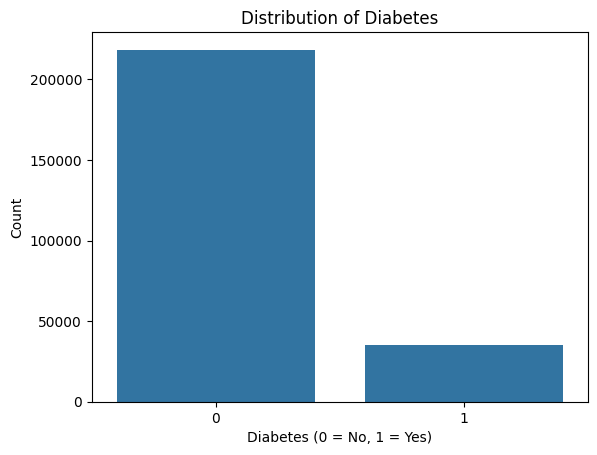

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Diabetes_binary', data=df)
plt.title('Distribution of Diabetes')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

##Age Distribution

<Axes: xlabel='Age_group', ylabel='Diabetes_binary'>

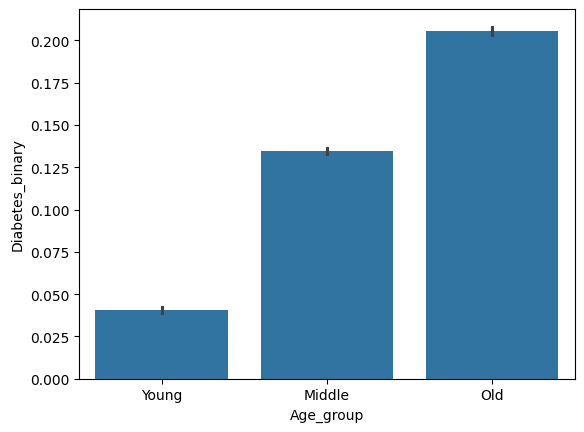

In [26]:
df['Age_group'] = pd.cut(df['Age'], bins=[0,5,9,13], labels=['Young','Middle','Old'])

sns.barplot(x='Age_group', y='Diabetes_binary', data=df)

## BMI vs Diabetes

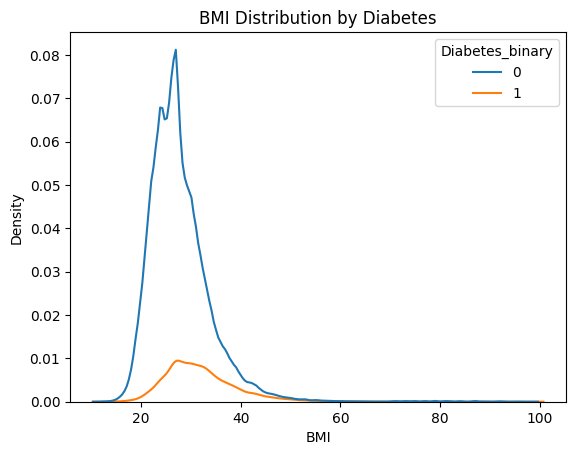

In [23]:
sns.kdeplot(data=df, x='BMI', hue='Diabetes_binary')

plt.title('BMI Distribution by Diabetes')
plt.show()

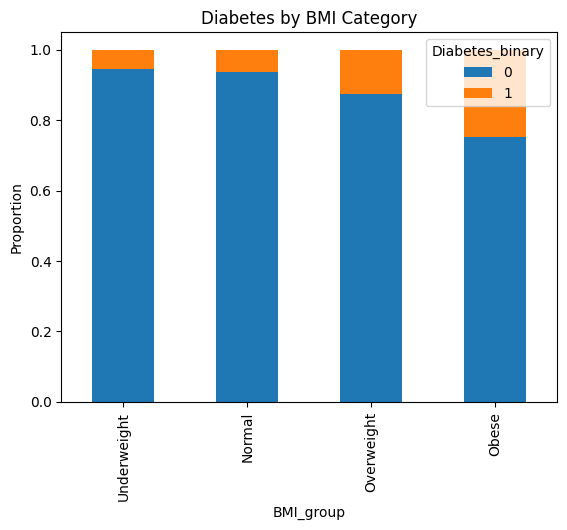

In [21]:
df['BMI_group'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,100],
                        labels=['Underweight','Normal','Overweight','Obese'])

ct = pd.crosstab(df['BMI_group'], df['Diabetes_binary'], normalize='index')

ct.plot(kind='bar', stacked=True)
plt.title('Diabetes by BMI Category')
plt.ylabel('Proportion')
plt.show()

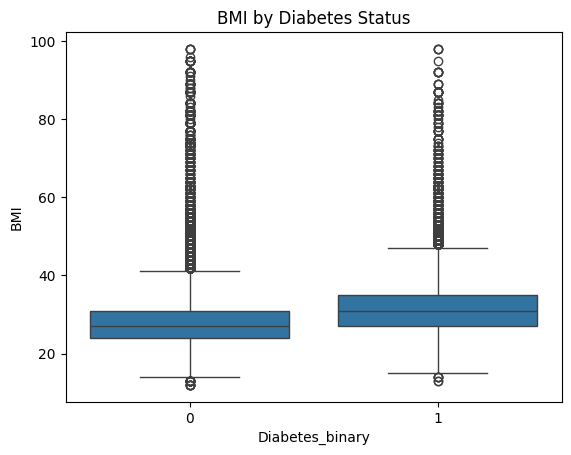

In [14]:
sns.boxplot(x='Diabetes_binary', y='BMI', data=df)
plt.title('BMI by Diabetes Status')
plt.show()

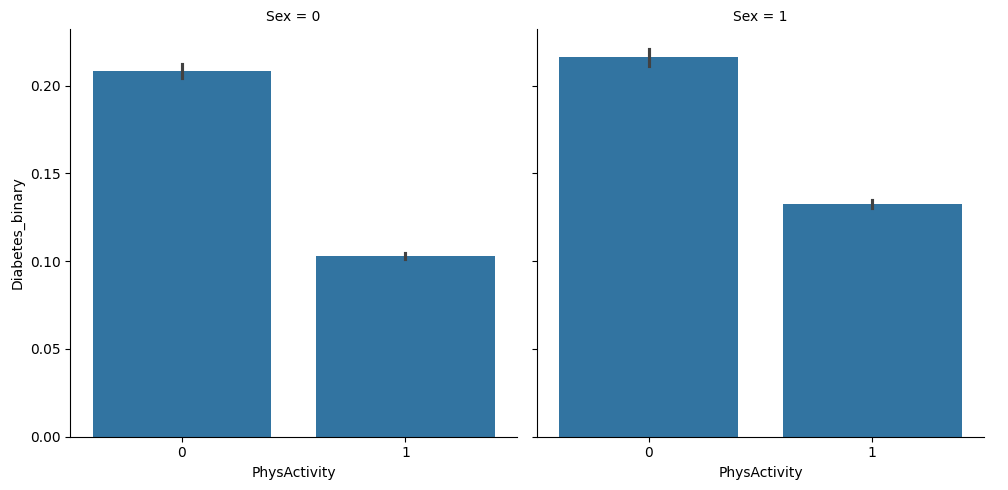

In [28]:
sns.catplot(x='PhysActivity', y='Diabetes_binary',
            col='Sex', kind='bar', data=df)

## Physical Activity vs Diabetes

###PhysActivity × HighBP

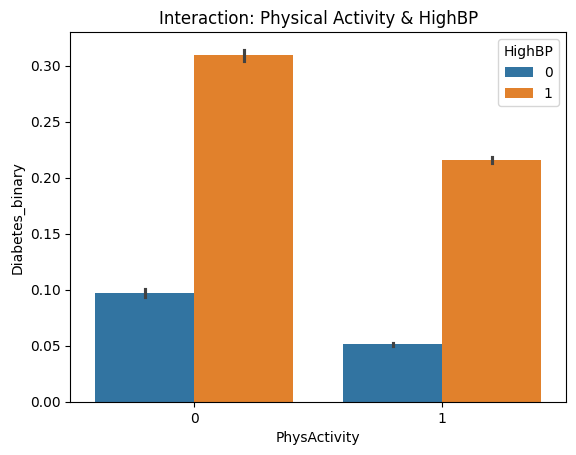

In [22]:
sns.barplot(x='PhysActivity', y='Diabetes_binary', hue='HighBP', data=df)

plt.title('Interaction: Physical Activity & HighBP')
plt.show()

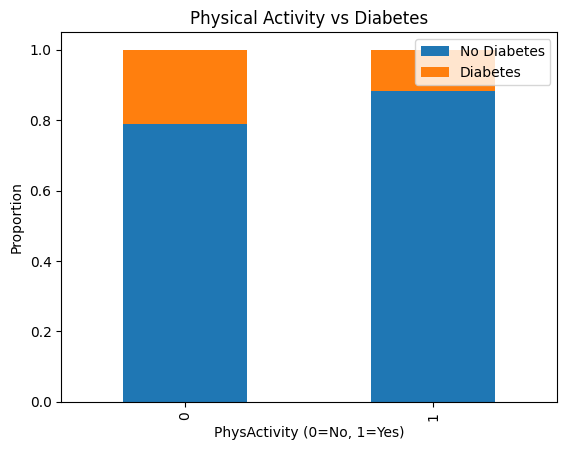

In [15]:
ct = pd.crosstab(df['PhysActivity'], df['Diabetes_binary'], normalize='index')
ct.plot(kind='bar', stacked=True)

plt.title('Physical Activity vs Diabetes')
plt.xlabel('PhysActivity (0=No, 1=Yes)')
plt.ylabel('Proportion')
plt.legend(['No Diabetes', 'Diabetes'])
plt.show()

## HighBP / HighChol vs Diabetes

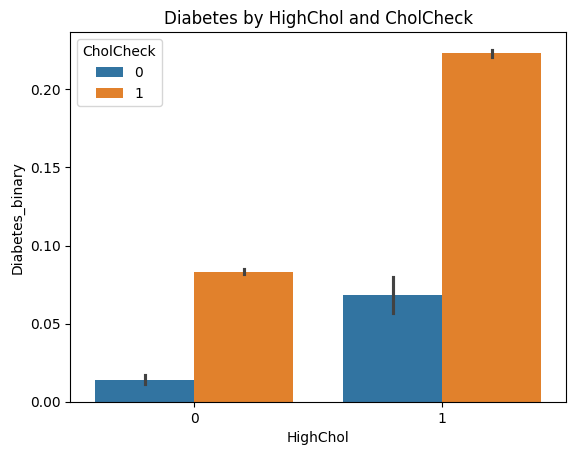

In [38]:
sns.barplot(x='HighChol', y='Diabetes_binary', hue='CholCheck', data=df)

plt.title('Diabetes by HighChol and CholCheck')
plt.show()

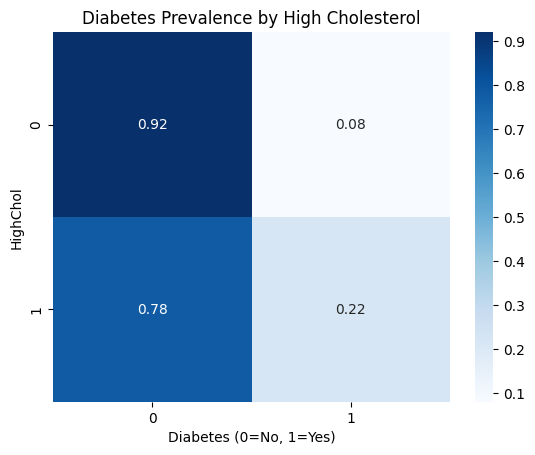

In [37]:
import seaborn as sns

ct = pd.crosstab(df['HighChol'], df['Diabetes_binary'], normalize='index')

sns.heatmap(ct, annot=True, fmt=".2f", cmap='Blues')

plt.title('Diabetes Prevalence by High Cholesterol')
plt.xlabel('Diabetes (0=No, 1=Yes)')
plt.ylabel('HighChol')
plt.show()

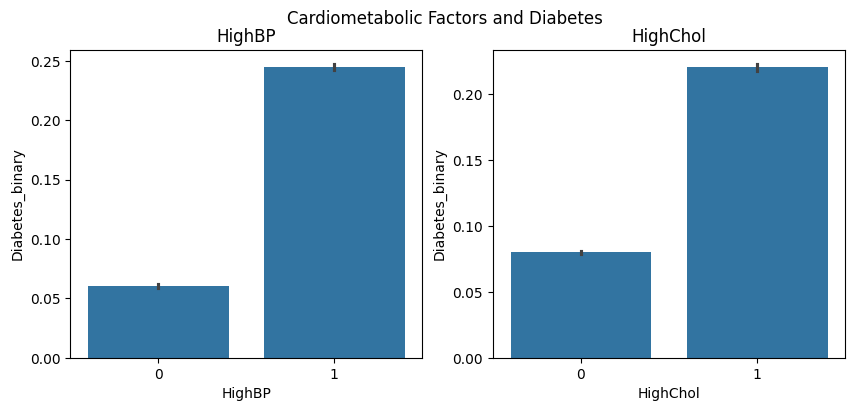

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.barplot(x='HighBP', y='Diabetes_binary', data=df, ax=axes[0])
axes[0].set_title('HighBP')

sns.barplot(x='HighChol', y='Diabetes_binary', data=df, ax=axes[1])
axes[1].set_title('HighChol')

plt.suptitle('Cardiometabolic Factors and Diabetes')
plt.show()

Text(50.722222222222214, 0.5, 'HighBP (0=No, 1=Yes)')

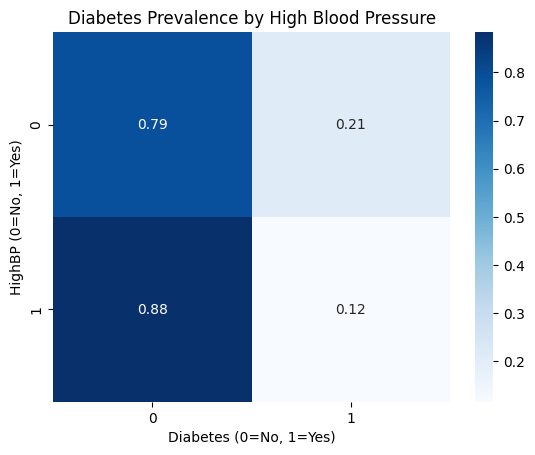

In [17]:
sns.heatmap(ct, annot=True, fmt=".2f", cmap='Blues')

plt.title('Diabetes Prevalence by High Blood Pressure')
plt.xlabel('Diabetes (0=No, 1=Yes)')
plt.ylabel('HighBP (0=No, 1=Yes)')

## General Health

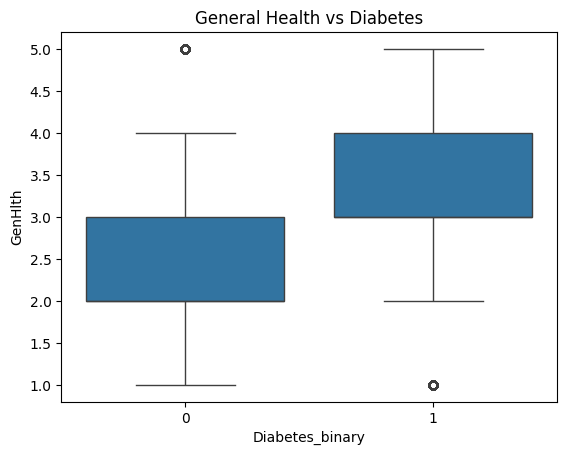

In [18]:
sns.boxplot(x='Diabetes_binary', y='GenHlth', data=df)
plt.title('General Health vs Diabetes')
plt.show()

In [42]:
vars_all = ['HighBP', 'HighChol', 'CholCheck', 'Stroke',
            'HeartDiseaseorAttack', 'Smoker', 'PhysActivity']

results = []

for var in vars_all:
    temp = df.groupby(var)['Diabetes_binary'].mean().reset_index()
    temp['Variable'] = var
    temp.columns = ['Group', 'Diabetes_rate', 'Variable']
    results.append(temp)

final_table = pd.concat(results)
final_table

,Group,Diabetes_rate,Variable
0,0,0.060352,HighBP
1,1,0.244457,HighBP
0,0,0.079814,HighChol
1,1,0.220149,HighChol
0,0,0.025449,CholCheck
1,1,0.143749,CholCheck
0,0,0.131798,Stroke
1,1,0.317528,Stroke
0,0,0.119537,HeartDiseaseorAttack
1,1,0.329720,HeartDiseaseorAttack


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

vars_all = ['HighBP', 'HighChol', 'CholCheck', 'Stroke',
            'HeartDiseaseorAttack', 'Smoker', 'PhysActivity']

heatmap_df = pd.DataFrame()

for var in vars_all:
    temp = df.groupby(var)['Diabetes_binary'].mean()
    heatmap_df[var] = temp

heatmap_df = heatmap_df.T

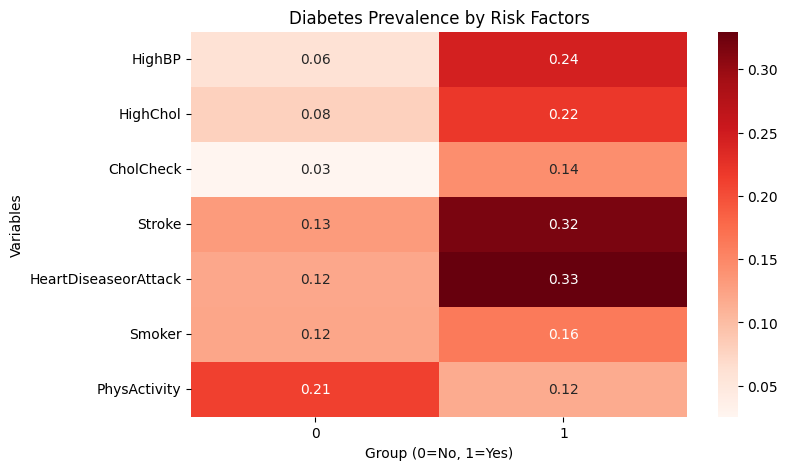

In [46]:
plt.figure(figsize=(8,5))

sns.heatmap(heatmap_df,
            annot=True,
            fmt=".2f",
            cmap='Reds')

plt.title('Diabetes Prevalence by Risk Factors')
plt.xlabel('Group (0=No, 1=Yes)')
plt.ylabel('Variables')

plt.show()